In [2]:
import polars as pl
import mysql.connector

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

In [3]:
conn = mysql.connector.connect(
    host="118.179.149.162",
    user="gazu",
    password="X9!qR7@MZf#2A$wL8pE",
    database="padakhep",
    port=8837,
    buffered=True
)

#conn.consume_results()

In [4]:
query = """
SELECT
z.name zone_name,
z.id zone_id,
z.pmuk_id zone_pmuk,
z.estd_date zone_estd_date,
z.is_active zone_status,



a.name area_name,
a.id area_id,
a.pmuk_id area_pmuk,
a.estd_date area_estd_date,
a.is_active area_status,


b.name as branch_name,
b.id branch_id,
b.pmuk_id branch_pmuk,
b.permanent_addr_thana,
b.estd_date branch_estd_date,
b.fundings,
b.is_active branch_status,

s.name shamity_name,
s.id shamity_id,
s.pmuk_id shamity_pmuk,
s.cm_employee_id,
s.member_cnt_initial,
s.member_cnt_min,
s.member_cnt_max,
s.shamity_type,
s.issue_date,
s.is_active shamity_ActiveStatus,
m.id  as member_id,
m.pmuk_id member_pmuk,
m.gender,
m.phone,
m.religion,
m.nationality,
m.passport_expire_date,
m.smart_card_id,
m.nid,
m.marital_status,
m.dob,
m.occupation,
m.occupation_alt,
m.education,
m.permanent_addr_division,
m.shamity_block,
m.introducer_relation,
m.loan_component,
m.total_family_member,
m.total_earning_member,
m.total_monthly_income,
m.yearly_total_income,
m.yearly_total_expenses,
m.yearly_total_savings,
m.home_owner_type,
m.year_of_rent,
m.farm_land_amt,
m.loan_use_sources,
m.is_active member_status,
m.admission_date,
m.inactive_date
from members m
LEFT JOIN shamities s on s.id = m.shamity_id
LEFT JOIN branches b ON b.pmuk_id = LEFT(s.pmuk_id, 6)
LEFT JOIN areas a ON a.pmuk_id = LEFT(b.pmuk_id, 4)
LEFT JOIN zones z ON z.pmuk_id = LEFT(a.pmuk_id, 2)
where m.admission_date between '2026-02-01' and '2026-04-30'
"""

In [5]:
df=pl.read_database(query, conn)

In [6]:
df.head()

zone_name,zone_id,zone_pmuk,zone_estd_date,zone_status,area_name,area_id,area_pmuk,area_estd_date,area_status,branch_name,branch_id,branch_pmuk,permanent_addr_thana,branch_estd_date,fundings,branch_status,shamity_name,shamity_id,shamity_pmuk,cm_employee_id,member_cnt_initial,member_cnt_min,member_cnt_max,shamity_type,issue_date,shamity_ActiveStatus,member_id,member_pmuk,gender,phone,religion,nationality,passport_expire_date,smart_card_id,nid,marital_status,dob,occupation,occupation_alt,education,permanent_addr_division,shamity_block,introducer_relation,loan_component,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_use_sources,member_status,admission_date,inactive_date
str,i64,str,date,str,str,i64,str,str,str,str,i64,str,str,str,str,str,str,i64,str,i64,i64,i64,i64,str,date,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,f64,f64,f64,f64,str,str,i64,str,str,str,str
"""Dhaka South Zone""",1,"""01""",2004-01-01,"""Yes""","""Mohammadpur Area""",3,"""0103""","""2010-03-29""","""Yes""","""Mohammadpur Urban Branch,Dhaka…",12,"""010302""","""Mohammadpur""","""2000-09-01""","""[""PKSF"",""BANK"",""PADAKHEP""]""","""Yes""","""Tista Purush Samity -02""",25849,"""010302119""",7981,10,5,30,"""MALE""",2024-05-24,"""Yes""",1186,"""010302119M18""","""Male""","""01616743365""","""Islam""","""Bangladeshi""","""0000-00-00""","""2852859350""","""19978519263000040""","""Single""","""1997-02-26""","""Service""","""""","""Pre-Primary""","""Rangpur""","""A""","""""",1,5,0,20000.0,240000.0,210000.0,30000.0,"""Rent""","""0""",63,"""<table align=""center"" border=""…","""Yes""","""2026-02-22""","""2025-12-23"""
"""Dhaka South Zone""",1,"""01""",2004-01-01,"""Yes""","""Mohammadpur Area""",3,"""0103""","""2010-03-29""","""Yes""","""Mohammadpur Urban Branch,Dhaka…",12,"""010302""","""Mohammadpur""","""2000-09-01""","""[""PKSF"",""BANK"",""PADAKHEP""]""","""Yes""","""Mukta Purush Samity-02""",25852,"""010302122""",7875,5,5,30,"""MALE""",2024-05-24,"""Yes""",1510,"""010302122M11""","""Male""","""01786285558""","""Islam""","""Bangladeshi""","""0000-00-00""","""9151881399""","""19925117339000331""","""Married""","""1992-01-01""","""Business""","""""","""Masters""","""Chattogram""","""B""","""Friend""",2,5,3,400000.0,4.8e6,1.8e6,3e6,"""Rent""","""07""",50,"""<table align=""center"" border=""…","""Yes""","""2026-04-15""","""2025-08-31"""
"""Dhaka South Zone""",1,"""01""",2004-01-01,"""Yes""","""Mohammadpur Area""",3,"""0103""","""2010-03-29""","""Yes""","""Mohammadpur Urban Branch,Dhaka…",12,"""010302""","""Mohammadpur""","""2000-09-01""","""[""PKSF"",""BANK"",""PADAKHEP""]""","""Yes""","""Akota Mohila Samity""",62,"""010302062""",7981,30,10,40,"""FEMALE""",2018-07-01,"""Yes""",1776,"""010302062M24""","""Female""","""01710180731""","""Hinduism""","""Bangladeshi""","""0000-00-00""","""5079114509""","""""","""Married""","""1982-09-28""","""Service""","""""","""Post-Graduation""","""Barishal""","""A""","""""",1,5,2,80000.0,960000.0,720000.0,240000.0,"""""","""0""",0,"""<table align=""center"" border=""…","""Yes""","""2026-02-16""","""2022-03-29"""
"""Dhaka South Zone""",1,"""01""",2004-01-01,"""Yes""","""Mohammadpur Area""",3,"""0103""","""2010-03-29""","""Yes""","""Mohammadpur Mahila Branch""",251,"""010306""","""Mohammadpur""","""2019-11-01""","""[""PKSF"",""BANK"",""PADAKHEP""]""","""Yes""","""Basanti Mohila Samity""",101,"""010306005""",33,35,5,40,"""FEMALE""",2019-11-21,"""Yes""",2821,"""010306005M22""","""Female""","""01710346111""","""Islam""","""Bangladeshi""","""0000-00-00""","""5533706221""","""19772692858548731""","""Married""","""1977-10-13""","""Housewife""","""""","""JSC""","""Dhaka""","""A""","""wife""",2,4,2,100000.0,1.2e6,840000.0,360000.0,"""Own""","""0""",0,"""<table align=""center"" border=""…","""Yes""","""2026-03-05""","""2021-09-08"""
"""Rangpur Zone""",3,"""03""",null,"""Yes""","""Patg

In [7]:
len(df)

44472

In [8]:
# save data on parquet format
df.write_parquet("member_demography.parquet")

### EDA

In [25]:
# !python -m pip install seaborn

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df=pd.read_parquet("member_demography.parquet")

In [3]:
df.head()

,zone_name,zone_id,zone_pmuk,zone_estd_date,zone_status,area_name,area_id,area_pmuk,area_estd_date,area_status,branch_name,branch_id,branch_pmuk,permanent_addr_thana,branch_estd_date,fundings,branch_status,shamity_name,shamity_id,shamity_pmuk,cm_employee_id,member_cnt_initial,member_cnt_min,member_cnt_max,shamity_type,issue_date,shamity_ActiveStatus,member_id,member_pmuk,gender,phone,religion,nationality,passport_expire_date,smart_card_id,nid,marital_status,dob,occupation,occupation_alt,education,permanent_addr_division,shamity_block,introducer_relation,loan_component,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_use_sources,member_status,admission_date,inactive_date
0,Dhaka South Zone,1,01,2004-01-01,Yes,Mohammadpur Area,3,0103,2010-03-29,Yes,"Mohammadpur Urban Branch,Dhaka South Zone",12,010302,Mohammadpur,2000-09-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Tista Purush Samity -02,25849,010302119,7981,10,5,30,MALE,2024-05-24,Yes,1186,010302119M18,Male,01616743365,Islam,Bangladeshi,0000-00-00,2852859350,19978519263000040,Single,1997-02-26,Service,,Pre-Primary,Rangpur,A,,1,5,0,20000.0,240000.0,210000.0,30000.0,Rent,0,63,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-22,2025-12-23
1,Dhaka South Zone,1,01,2004-01-01,Yes,Mohammadpur Area,3,0103,2010-03-29,Yes,"Mohammadpur Urban Branch,Dhaka South Zone",12,010302,Mohammadpur,2000-09-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Mukta Purush Samity-02,25852,010302122,7875,5,5,30,MALE,2024-05-24,Yes,1510,010302122M11,Male,01786285558,Islam,Bangladeshi,0000-00-00,9151881399,19925117339000331,Married,1992-01-01,Business,,Masters,Chattogram,B,Friend,2,5,3,400000.0,4800000.0,1800000.0,3000000.0,Rent,07,50,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-04-15,2025-08-31
2,Dhaka South Zone,1,01,2004-01-01,Yes,Mohammadpur Area,3,0103,2010-03-29,Yes,"Mohammadpur Urban Branch,Dhaka South Zone",12,010302,Mohammadpur,2000-09-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Akota Mohila Samity,62,010302062,7981,30,10,40,FEMALE,2018-07-01,Yes,1776,010302062M24,Female,01710180731,Hinduism,Bangladeshi,0000-00-00,5079114509,,Married,1982-09-28,Service,,Post-Graduation,Barishal,A,,1,5,2,80000.0,960000.0,720000.0,240000.0,,0,0,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-16,2022-03-29
3,Dhaka South Zone,1,01,2004-01-01,Yes,Mohammadpur Area,3,0103,2010-03-29,Yes,Mohammadpur Mahila Branch,251,010306,Mohammadpur,2019-11-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Basanti Mohila Samity,101,010306005,33,35,5,40,FEMALE,2019-11-21,Yes,2821,010306005M22,Female,01710346111,Islam,Bangladeshi,0000-00-00,5533706221,19772692858548731,Married,1977-10-13,Housewife,,JSC,Dhaka,A,wife,2,4,2,100000.0,1200000.0,840000.0,360000.0,Own,0,0,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-05,2021-09-08
4,Rangpur Zone,3,03,None,Yes,Patgram Area,12,0302,2010-03-10,Yes,Jagatber Branch,61,030204,Patgram,,"[""1""]",Yes,Kallani Mohila Shamity,2472,030204067,1806,10,10,100,FEMALE,2007-06-18,Yes,3446,030204067M1,Female,01881383832,Islam,Bangladeshi,,6474118376,19965217027000688,Married,1996-11-19,Housewife,,Primary,Rangpur,A,ja,1,3,1,26000.0,312000.0,120000.0,72000.0,Own,0,100,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-19,2025-12-14


In [18]:
df.columns

Index(['zone_name', 'zone_id', 'zone_pmuk', 'zone_estd_date', 'zone_status',
       'area_name', 'area_id', 'area_pmuk', 'area_estd_date', 'area_status',
       'branch_name', 'branch_id', 'branch_pmuk', 'permanent_addr_thana',
       'branch_estd_date', 'fundings', 'branch_status', 'shamity_name',
       'shamity_id', 'shamity_pmuk', 'cm_employee_id', 'member_cnt_initial',
       'member_cnt_min', 'member_cnt_max', 'shamity_type', 'issue_date',
       'shamity_ActiveStatus', 'member_id', 'member_pmuk', 'gender', 'phone',
       'religion', 'nationality', 'passport_expire_date', 'smart_card_id',
       'nid', 'marital_status', 'dob', 'occupation', 'occupation_alt',
       'education', 'permanent_addr_division', 'shamity_block',
       'introducer_relation', 'loan_component', 'total_family_member',
       'total_earning_member', 'total_monthly_income', 'yearly_total_income',
       'yearly_total_expenses', 'yearly_total_savings', 'home_owner_type',
       'year_of_rent', 'farm_land_amt'

In [19]:
df.shape

(44472, 58)

In [ ]:
# std << mean
# 2+100-2

In [20]:
df.describe()

,zone_id,area_id,branch_id,shamity_id,cm_employee_id,member_cnt_initial,member_cnt_min,member_cnt_max,member_id,loan_component,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,farm_land_amt
count,44472.000000,44472.000000,44472.000000,44472.000000,44472.000000,4.447200e+04,44472.000000,44472.000000,4.447200e+04,44472.000000,44472.000000,44472.00000,4.447200e+04,4.447200e+04,4.447200e+04,4.447200e+04,4.447200e+04
mean,10.445179,51.966631,222.158909,17300.775724,4630.916374,7.763654e+02,6.483158,38.235789,1.225708e+06,2.011558,3.964067,1.69727,7.152491e+04,8.582989e+05,3.089872e+05,5.543232e+05,9.051014e+03
std,6.008330,29.319041,132.264818,9460.768906,2363.623672,1.144858e+05,15.339369,67.688718,2.310715e+05,2.551055,1.097572,0.71890,1.614002e+05,1.936802e+06,4.803927e+05,1.829912e+06,7.589718e+05
min,1.000000,2.000000,1.000000,2.000000,0.000000,0.000000e+00,0.000000,0.000000,1.186000e+03,1.000000,0.000000,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.000000,28.000000,115.000000,9361.750000,2731.000000,0.000000e+00,0.000000,0.000000,1.290764e+06,1.000000,3.000000,1.00000,3.500000e+04,4.200000e+05,1.500000e+05,2.000000e+05,0.000000e+00
50%,9.000000,46.000000,207.000000,17646.000000,4634.000000,5.000000e+00,5.000000,35.000000,1.301884e+06,1.000000,4.000000,2.00000,5.000000e+04,6.000000e+05,2.400000e+05,3.000000e+05,2.000000e+01
75%,15.000000,77.000000,326.000000,25706.250000,6663.000000,1.000000e+01,10.000000,50.000000,1.313007e+06,2.000000,4.000000,2.00000,7.000000e+04,8.400000e+05,3.600000e+05,4.800000e+05,5.000000e+01
max,30.000000,126.000000,581.000000,32465.000000,8490.000000,1.707202e+07,1035.000000,5040.000000,1.324139e+06,35.000000,23.000000,8.00000,1.300000e+07,1.560000e+08,3.000000e+07,1.554000e+08,1.043120e+08


In [35]:
df.describe(include='object')

,zone_name,zone_pmuk,zone_estd_date,zone_status,area_name,area_pmuk,area_estd_date,area_status,branch_name,branch_pmuk,permanent_addr_thana,branch_estd_date,fundings,branch_status,shamity_name,shamity_pmuk,shamity_type,issue_date,shamity_ActiveStatus,member_pmuk,gender,phone,religion,nationality,passport_expire_date,smart_card_id,nid,marital_status,dob,occupation,occupation_alt,education,permanent_addr_division,shamity_block,introducer_relation,home_owner_type,year_of_rent,loan_use_sources,member_status,admission_date,inactive_date
count,44472,44472,34569,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44433,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472,44472
unique,30,30,9,1,113,113,60,1,567,567,272,149,8,1,10050,17477,2,5343,2,44472,2,44470,6,2,250,43201,36937,5,11489,7,2191,18,8,7,2303,5,67,5321,2,71,860
top,B-Baria Zone,06,2012-07-01,Yes,Bhola,1101,2010-03-01,Yes,Godkhali Branch,050503,Gaffargaon,,"[""1""]",Yes,Cluster-1 Mohila Samity,270201003,FEMALE,2026-05-02,Yes,120306033M93,Female,,Islam,Bangladeshi,,,,Married,1990-01-01,Housewife,,Pre-Primary,Chattogram,A,,Own,0,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-04-09,
freq,3711,3711,10558,44472,1016,1016,4823,44472,221,221,1126,17396,24258,44472,354,28,39770,1087,44403,1,39770,3,41533,44456,43682,1265,7530,43560,252,34022,29450,21011,9821,41354,15393,33522,43224,25563,42158,1452,36586


In [49]:
from IPython.display import display
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': [df[col].dtype for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Missing Values': [df[col].isnull().sum() for col in df.columns],
    'Missing %': [(df[col].isnull().mean() * 100).round(2) for col in df.columns]
})

display(summary)

,Column,Data Type,Unique Values,Missing Values,Missing %
0,zone_name,object,30,0,0.00
1,zone_id,int64,30,0,0.00
2,zone_pmuk,object,30,0,0.00
3,zone_estd_date,object,9,9903,22.27
4,zone_status,object,1,0,0.00
5,area_name,object,113,0,0.00
6,area_id,int64,113,0,0.00
7,area_pmuk,object,113,0,0.00
8,area_estd_date,object,60,0,0.00
9,area_status,object,1,0,0.00


### member admission flow

In [70]:
df['admission_date'] = pd.to_datetime(df['admission_date'], errors='coerce')
df.groupby(df['admission_date'].dt.month_name()).size()

admission_date
April       20274
February    13437
March       10761
dtype: int64

In [73]:
df.groupby([
    df['admission_date'].dt.month_name(),
    'member_status'
]).size()

admission_date  member_status
April           No                 704
                Yes              19570
February        No                 994
                Yes              12443
March           No                 616
                Yes              10145
dtype: int64

### component

In [74]:
#jagoron, agrosor,primary
df['loan_component'].value_counts(dropna=False)

loan_component
1     30366
5      8133
2      5742
30      162
35       40
31        9
28        6
20        4
9         3
12        3
19        2
23        1
32        1
Name: count, dtype: int64

### Monitoring columns

In [110]:
df['introducer_relation'].value_counts()

introducer_relation
                                                                                           15393
Neighbour                                                                                   4349
Neighbour                                                                                   1389
Protibesi                                                                                   1135
Protibeshi                                                                                  1077
Neighbours                                                                                  1019
Ja                                                                                           812
Sister                                                                                       618
Neibour                                                                                      469
Neighbor                                                                                     451
Neighbors 

In [112]:
# df['loan_use_sources'].value_counts()

In [113]:
df['year_of_rent'].value_counts()

year_of_rent
0        43224
10         203
5          177
3           96
4           73
2           67
15          65
8           63
7           56
6           55
12          48
            37
1           33
20          31
05          29
13          17
9           16
04          15
25          15
010         14
07          11
11          10
16          10
14           9
18           8
06           6
30           6
015          6
03           6
17           5
19           5
21           5
02           4
08           4
5000         3
01           3
09           2
025          2
40           2
012          2
7000         2
013          2
9            1
7            1
32           1
34           1
4000         1
12000        1
10           1
6000         1
011          1
35000        1
09000        1
3            1
 5           1
018          1
20009        1
2.5          1
15           1
26           1
24           1
035          1
22           1
23           1
10000        1
8000        

In [121]:
df['loan_use_sources'].head()

0    <table align="center" border="1" cellpadding="...
1    <table align="center" border="1" cellpadding="...
2    <table align="center" border="1" cellpadding="...
3    <table align="center" border="1" cellpadding="...
4    <table align="center" border="1" cellpadding="...
Name: loan_use_sources, dtype: object

In [117]:
from bs4 import BeautifulSoup

def extract_loan_use(html):
    soup = BeautifulSoup(str(html), "html.parser")
    texts = [p.get_text(strip=True) for p in soup.find_all('p')]
    texts = [t for t in texts if t and 'ঋণ ব্যবহারের ক্ষেত্র' not in t]
    return ', '.join(texts)

df['loan_use_clean'] = df['loan_use_sources'].apply(extract_loan_use)

In [118]:
df['loan_use_clean']

0                                                         
1                                   Ready clothes business
2                                                         
3                             House building rent for loan
4                                                   AtuBay
5                                     Business, Direy Farm
6                                              Agriculture
7                                              Jomi Bondok
8                                                         
9                                                         
10                                                business
11                                                        
12                                                Business
13                                          immigrant loan
14                                             Home Repair
15                                  Mobile phone  business
16                                  Business, Car Purcha

### shamity

In [67]:
df.groupby('shamity_type')['shamity_id'].nunique()

shamity_type
FEMALE    15389
MALE       2088
Name: shamity_id, dtype: int64

In [63]:
df['shamity_type'].value_counts(dropna=False)

shamity_type
FEMALE    39770
MALE       4702
Name: count, dtype: int64

In [64]:
df['shamity_name'].value_counts(dropna=False)

shamity_name
Cluster-1 Mohila Samity                                                                                 354
Cluster-2 Mohila Samity                                                                                 301
Joba Mohila Samity                                                                                      232
Shapla Mohila Samity                                                                                    225
Golap Mohila Samity                                                                                     213
Bokul Mohila Samity                                                                                     206
Jui Mohila Samity                                                                                       195
Sonali Mohila Samity                                                                                    192
Jamuna Mohila Samity                                                                                    182
Padma Mohila Sa

In [80]:
df[df['shamity_name']=='Cluster-1 Mohila Samity'].head(40)

,zone_name,zone_id,zone_pmuk,zone_estd_date,zone_status,area_name,area_id,area_pmuk,area_estd_date,area_status,branch_name,branch_id,branch_pmuk,permanent_addr_thana,branch_estd_date,fundings,branch_status,shamity_name,shamity_id,shamity_pmuk,cm_employee_id,member_cnt_initial,member_cnt_min,member_cnt_max,shamity_type,issue_date,shamity_ActiveStatus,member_id,member_pmuk,gender,phone,religion,nationality,passport_expire_date,smart_card_id,nid,marital_status,dob,occupation,occupation_alt,education,permanent_addr_division,shamity_block,introducer_relation,loan_component,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_use_sources,member_status,admission_date,inactive_date,age,age_group
610,Mymensingh Zone (PME),27,27,2012-07-01,Yes,Gafargaon Area (PME),123,2702,2008-06-01,Yes,Pagla Branch (PME),540,270205,Gaffargaon,2023-06-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Cluster-1 Mohila Samity,32287,270205001,7192,30,10,30,FEMALE,2026-01-02,Yes,240684,270205001M118,Female,01306367620,Islam,Bangladeshi,,4180331599,19776112218905779,Married,1977-10-07,Housewife,Agriculture,Secondary,Mymensingh,C,,2,6,2,100000.0,1200000.0,200000.0,160000.0,,0,0,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-04-09,2024-09-15,49.0,41-50
1193,Patuakhali Zone (PME),29,29,2012-07-01,Yes,Amtoli (PME),112,2902,2010-02-01,Yes,Amtali Branch (PME),548,290202,Amtali,2003-09-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Cluster-1 Mohila Samity,31749,290202001,2739,30,10,150,FEMALE,2026-05-02,Yes,431146,290202001M49,Female,01749386738,Islam,Bangladeshi,,6858942649,19780410915594334,Married,1978-03-21,Housewife,,Pre-Primary,Barishal,D,Vavi,2,3,1,50000.0,600000.0,350000.0,250000.0,Own,0,46,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-09,2023-08-31,48.0,41-50
1288,Mymensingh Zone (PME),27,27,2012-07-01,Yes,Gafargaon Area (PME),123,2702,2008-06-01,Yes,Gayeshpur Branch (PME),535,270202,Gaffargaon,2003-02-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Cluster-1 Mohila Samity,32192,270202001,3201,25,10,25,FEMALE,2026-01-01,Yes,449162,270202001M164,Female,01778699660,Islam,Bangladeshi,,2829819461,19896112250871124,Married,1989-10-05,Agriculture,Service,Pre-Primary,Mymensingh,A,Protibeshi,2,5,1,80000.0,960000.0,380000.0,7060000.0,Own,0,200,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-10,2026-01-25,37.0,31-40
1430,Rajshahi Zone (PME),30,30,2010-04-07,Yes,Taherpur Area (PME),100,3001,2015-07-15,Yes,Keshorhat Branch (PME),556,300102,Bogra Sader,2009-08-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Cluster-1 Mohila Samity,32094,300102001,3767,65,10,40,FEMALE,2026-05-02,Yes,477383,300102001M28,Female,01745615541,Islam,Bangladeshi,,3719496865,19888115354462230,Married,1988-04-04,Housewife,,Secondary,Rajshahi,A,Sister,2,4,2,95000.0,1140000.0,800000.0,280000.0,Own,0,90,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-17,2023-12-18,38.0,31-40
1554,Mymensingh Zone (PME),27,27,2012-07-01,Yes,Bhaluka Area (PME),121,2701,2023-11-01,Yes,Bhaluka Branch (PME),563,270106,Bhaluka,2001-04-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Cluster-1 Mohila Samity,32182,270106002,1525,80,10,200,FEMALE,2026-05-02,Yes,505125,270106002M3,Female,01403815718,Islam,Bangladeshi,,5521294701,19816111386828578,Married,1981-11-09,Housewife,others,Pre-Primary,Mymensingh,A,Neighbor,2,4,2,80000.0,960000.0,620000.0,340000.0,Own,0,100,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-04-20,2024-03-31,45.0,41-50
1795,B-Baria Zone (PME),21,21,2008-03-01,Yes,Brahmanbaria Area (PME),96,2101,2004-03-11,Yes,"Lalpur Branch, B.Baria Zone (PME)",443,210104,Brahmanbaria,2007-05-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Cluster-1 Mohila Samity,31917,210104001,2534,100,5,300,FEMALE,2026-05-01,Yes,550420,210104001M99,Female,01845745593,Islam,Bangladeshi,,6004068893,19941218581000339,Married,1994-03-05,Housewife,,Pre-Primar

### DOB

In [53]:
# print(df['dob'].value_counts(dropna=False).to_string())
df['dob'].value_counts(dropna=False)

dob
1990-01-01    252
1988-01-01    248
1992-01-01    190
1989-01-01    186
1983-01-01    154
1995-01-01    153
1986-01-01    148
1997-01-01    146
2000-01-01    144
1996-01-01    134
1994-01-01    134
1998-01-01    121
1985-01-01    113
1987-01-01    111
1978-01-01    106
1982-01-01    100
1980-01-01     96
1993-01-01     96
1984-01-01     93
1999-01-01     92
1991-01-01     84
2001-01-01     80
1973-01-01     68
2003-01-01     67
2004-01-01     63
1981-01-01     63
1988-02-01     61
2002-01-01     56
1977-01-01     54
1989-02-01     50
1979-01-01     45
1987-02-01     45
1972-01-01     45
1985-02-01     43
2005-01-01     43
1983-02-01     43
1970-01-01     42
2006-01-01     41
1982-02-01     41
1993-02-01     39
1976-01-01     38
1995-02-01     37
1983-03-01     37
1985-03-01     35
2007-01-01     35
1975-01-01     35
1994-02-01     34
1996-02-01     33
1997-02-01     33
1982-03-01     33
2002-02-01     32
1994-03-01     31
1982-07-05     30
1986-03-01     30
1968-01-01     29
1987-0

In [86]:
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

current_year = pd.Timestamp.now().year
df['age'] = current_year - df['dob'].dt.year

bins = [0, 17, 24, 30, 40, 60, 70]
labels = ['0-17', '18-24', '25-30', '31-40', '41-50', '50-60' '60+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

df['age_group'].value_counts(dropna=False)

age_group
41-50       17767
31-40       14952
25-30        7324
18-24        4349
50-6060+       58
NaN            16
0-17            6
Name: count, dtype: int64

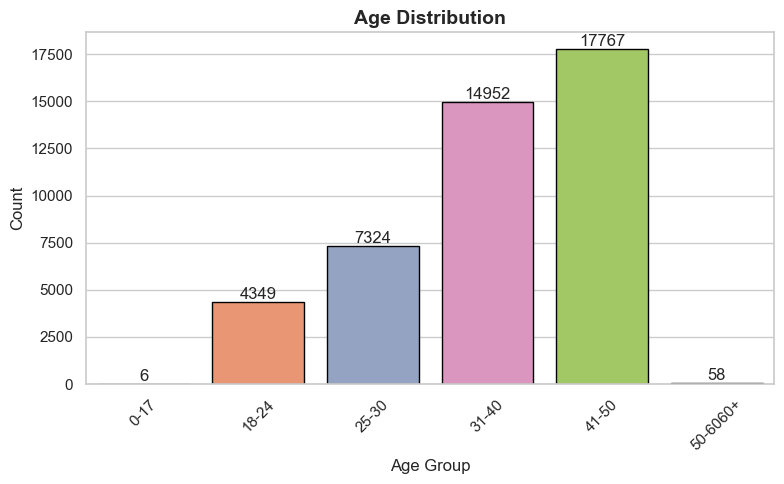

In [87]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='age_group',
    hue='age_group',
    palette='Set2',
    dodge=False,
    legend=False,
    edgecolor='black'
)

plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)

# value labels (extra nice touch)
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [55]:
df[df['dob'] == '1990-01-01']

,zone_name,zone_id,zone_pmuk,zone_estd_date,zone_status,area_name,area_id,area_pmuk,area_estd_date,area_status,branch_name,branch_id,branch_pmuk,permanent_addr_thana,branch_estd_date,fundings,branch_status,shamity_name,shamity_id,shamity_pmuk,cm_employee_id,member_cnt_initial,member_cnt_min,member_cnt_max,shamity_type,issue_date,shamity_ActiveStatus,member_id,member_pmuk,gender,phone,religion,nationality,passport_expire_date,smart_card_id,nid,marital_status,dob,occupation,occupation_alt,education,permanent_addr_division,shamity_block,introducer_relation,loan_component,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_use_sources,member_status,admission_date,inactive_date,age,age_group
235,B-Baria Zone,6,06,2008-03-01,Yes,Ashuganj Area,26,0605,2012-07-01,Yes,Panishwar Branch,131,060502,Sarail,,"[""1""]",Yes,Chuta Nadi Mohila Shamity,2389,060502044,1059,0,0,0,FEMALE,2013-03-15,Yes,110575,060502044M12,Female,01947947141,Islam,Bangladeshi,0000-00-00,9110859114,19901219494407197,Married,1990-01-01,Housewife,Housewife,Illiterate,Chattogram,A,Sister,1,6,3,40000.0,480000.0,150000.0,330000.0,Own,0,1,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-04-21,2025-12-22,36.0,31-40
481,Patuakhali Zone,10,10,2012-07-01,Yes,Amtoli,41,1002,2010-03-01,Yes,"Gazipur Branch, Patuakhali Zone",208,100205,Amtali,,"[""1""]",Yes,Rupchada Mohila Samity,7797,100205069,7470,0,5,45,FEMALE,2016-11-26,Yes,202057,100205069M20,Female,01734339420,Islam,Bangladeshi,0000-00-00,6412072974,19900410971000203,Married,1990-01-01,Agriculture,Razmistori,Primary,Barishal,B,Neighbor,1,4,1,30000.0,360000.0,180000.0,180000.0,Own,0,35,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-18,2026-01-07,36.0,31-40
623,Mymensingh Zone,8,08,2012-07-01,Yes,Mymensingh Area,33,0802,2002-02-01,Yes,Balipara Branch,262,080208,Trishal,2019-11-03,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Jomuna Mohila Somity,12004,080208036,3772,0,0,0,FEMALE,2020-08-24,Yes,244210,080208036M95,Female,01810429174,Islam,Bangladeshi,,1916634197,19906119447112947,Married,1990-01-01,Housewife,Remittance,Higher-Secondary,Mymensingh,D,,2,4,2,155000.0,1860000.0,550000.0,1310000.0,Own,0,150,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-04-17,2023-05-22,36.0,31-40
846,Dhaka North Zone,19,19,2023-11-01,Yes,Sreepur Area,88,1903,2010-03-01,Yes,Prahladpur Branch,174,190302,Sreepur,2000-05-02,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Chopola Mohila Samity,10737,190302050,3518,0,0,0,FEMALE,2010-08-01,Yes,309898,190302050M7,Female,01952391239,Islam,Bangladeshi,,7750446937,19903318657423931,Married,1990-01-01,Housewife,Immigrant,Primary,Dhaka,A,Neighbour,5,2,1,68000.0,816000.0,300000.0,516000.0,Own,0,50,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-05,2022-02-26,36.0,31-40
978,Cumilla Zone,16,16,2022-11-01,Yes,Homna Area,54,1601,2022-09-01,Yes,Ramkrishnapur Branch,128,160104,Homna,,"[""1""]",Yes,Bely Mohila Samity,14291,160104006,2630,0,1,100,FEMALE,2006-08-25,Yes,352377,160104006M16,Female,01401315086,Islam,Bangladeshi,,7801583290,19901915428000379,Married,1990-01-01,Housewife,Agriculture,Pre-Primary,Chattogram,A,Ja,1,3,1,45000.0,540000.0,350000.0,190000.0,Own,0,5,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-02,2022-08-31,36.0,31-40
1047,B-Baria Zone,6,06,2008-03-01,Yes,Sylhet Area,27,0606,2013-05-01,Yes,Jalalabad Branch,402,060606,Jalalabad,2024-05-15,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Mohona Mohila Samity,25783,060606006,6932,5,5,30,FEMALE,2024-05-21,Yes,375879,060606006M39,Female,01752212662,Islam,Bangladeshi,,5528177339,19909116232423662,Married,1990-01-01,Housewife,Driving,Pre-Primary,Sylhet,A,Patubashe,1,4,2,30000.0,360000.0,180000.0,180000.0,Own,0,90,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-04-07,2022-04-28,36.0,31-40
1141,Faridpur Zone,13,13,None,Yes,Gopalganj,46,1301,2003-0

In [57]:
df[(df['age'] >= 41) & (df['age'] <= 50)].head()

,zone_name,zone_id,zone_pmuk,zone_estd_date,zone_status,area_name,area_id,area_pmuk,area_estd_date,area_status,branch_name,branch_id,branch_pmuk,permanent_addr_thana,branch_estd_date,fundings,branch_status,shamity_name,shamity_id,shamity_pmuk,cm_employee_id,member_cnt_initial,member_cnt_min,member_cnt_max,shamity_type,issue_date,shamity_ActiveStatus,member_id,member_pmuk,gender,phone,religion,nationality,passport_expire_date,smart_card_id,nid,marital_status,dob,occupation,occupation_alt,education,permanent_addr_division,shamity_block,introducer_relation,loan_component,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_use_sources,member_status,admission_date,inactive_date,age,age_group
2,Dhaka South Zone,1,01,2004-01-01,Yes,Mohammadpur Area,3,0103,2010-03-29,Yes,"Mohammadpur Urban Branch,Dhaka South Zone",12,010302,Mohammadpur,2000-09-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Akota Mohila Samity,62,010302062,7981,30,10,40,FEMALE,2018-07-01,Yes,1776,010302062M24,Female,01710180731,Hinduism,Bangladeshi,0000-00-00,5079114509,,Married,1982-09-28,Service,,Post-Graduation,Barishal,A,,1,5,2,80000.0,960000.0,720000.0,240000.0,,0,0,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-16,2022-03-29,44.0,41-50
3,Dhaka South Zone,1,01,2004-01-01,Yes,Mohammadpur Area,3,0103,2010-03-29,Yes,Mohammadpur Mahila Branch,251,010306,Mohammadpur,2019-11-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Basanti Mohila Samity,101,010306005,33,35,5,40,FEMALE,2019-11-21,Yes,2821,010306005M22,Female,01710346111,Islam,Bangladeshi,0000-00-00,5533706221,19772692858548731,Married,1977-10-13,Housewife,,JSC,Dhaka,A,wife,2,4,2,100000.0,1200000.0,840000.0,360000.0,Own,0,0,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-05,2021-09-08,49.0,41-50
5,Dinajpur Zone,9,09,None,Yes,Saidpur Area,38,0903,2007-08-24,Yes,Nilphamari Sadar Branch,191,090303,Nilphamari,2004-09-01,"[""1""]",Yes,Shuborna Mohila Samity,6465,090303031,499,10,10,15,FEMALE,2017-02-20,Yes,3504,090303031M1,Female,01309466078,Islam,Bangladeshi,,8225508616,19827316444475914,Married,1982-06-01,Housewife,Agricuthuc,JSC,Rangpur,D,Patursb,1,3,2,47000.0,564000.0,120000.0,204000.0,Own,0,30,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-24,2025-07-15,44.0,41-50
6,Faridpur Zone,13,13,None,Yes,Faridpur,48,1303,2010-03-01,Yes,Kanaipur Branch,243,130301,Faridpur Sadar,,"[""1""]",Yes,Golap Mohila Samity,3109,130301059,2409,0,0,0,FEMALE,2008-05-20,Yes,3513,130301059M53,Female,01747056472,Islam,Bangladeshi,,2352427203,19782914763398538,Married,1978-01-01,Housewife,,Primary,Dhaka,B,Neiber,1,3,2,70000.0,840000.0,360000.0,480000.0,Own,0,40,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-12,2024-01-24,48.0,41-50
7,Rangpur Zone,3,03,None,Yes,Haragach,89,0305,2024-02-01,Yes,Gangachara Branch,53,030502,Gangachara,,"[""1""]",Yes,Balaka Mohila Samity,8254,030502076,1801,0,0,0,FEMALE,2009-06-08,Yes,3521,030502076M2,Female,01341374818,Islam,Bangladeshi,,3296856408,19798512719750666,Married,1979-04-09,Housewife,Agriculture,Primary,Rangpur,C,Ja,1,4,3,40000.0,480000.0,216000.0,168000.0,Own,0,72,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-02-02,2025-01-09,47.0,41-50


### education

In [104]:
df['education'].value_counts(dropna=False)

education
Pre-Primary         21011
Primary             11200
Secondary            6552
Higher-Secondary     1539
JSC                  1157
Graduation            797
SSC                   723
PSC                   640
HSC                   326
Post-Graduation       150
Honors                 91
Illiterate             84
Masters                75
Literacy               59
Degree                 44
Others                 21
                        2
PHD                     1
Name: count, dtype: int64

In [105]:
df.groupby(['education', 'gender']).size().unstack(fill_value=0)

gender,Female,Male
education,,
,0,2
Degree,26,18
Graduation,445,352
HSC,190,136
Higher-Secondary,1097,442
Honors,51,40
Illiterate,83,1
JSC,985,172
Literacy,57,2


### Occupation

In [107]:
df['occupation'].value_counts()

occupation
Housewife        34022
Business          6751
Service           1586
Agriculture       1400
Self-Employed      491
Others             221
House wife           1
Name: count, dtype: int64

In [108]:
df.groupby(['occupation', 'gender']).size().unstack(fill_value=0)

gender,Female,Male
occupation,,
Agriculture,1311,89
Business,2766,3985
House wife,1,0
Housewife,33839,183
Others,202,19
Self-Employed,411,80
Service,1240,346


### Family Member Count

In [54]:
df['total_family_member'].value_counts(dropna=False)

total_family_member
4     19015
3     12087
5      7869
2      2368
6      2175
7       506
8       222
9        70
0        68
10       46
12       16
1        14
11        5
13        3
15        3
14        2
23        1
18        1
16        1
Name: count, dtype: int64

In [59]:
df[(df['total_family_member'] >= 9) & (df['total_family_member'] <= 10)].head()

,zone_name,zone_id,zone_pmuk,zone_estd_date,zone_status,area_name,area_id,area_pmuk,area_estd_date,area_status,branch_name,branch_id,branch_pmuk,permanent_addr_thana,branch_estd_date,fundings,branch_status,shamity_name,shamity_id,shamity_pmuk,cm_employee_id,member_cnt_initial,member_cnt_min,member_cnt_max,shamity_type,issue_date,shamity_ActiveStatus,member_id,member_pmuk,gender,phone,religion,nationality,passport_expire_date,smart_card_id,nid,marital_status,dob,occupation,occupation_alt,education,permanent_addr_division,shamity_block,introducer_relation,loan_component,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_use_sources,member_status,admission_date,inactive_date,age,age_group
1069,B-Baria Zone,6,06,2008-03-01,Yes,Sylhet Area,27,0606,2013-05-01,Yes,Chhatak Branch,135,060601,Chhatak,2005-11-01,"[""1""]",Yes,Mitali Mohila Samity,14785,060601055,5403,0,0,0,FEMALE,2014-08-14,Yes,386430,060601055M11,Female,01770069718,Islam,Bangladeshi,,2835116530,19729012342615599,Married,1972-06-12,Housewife,Babsa,Pre-Primary,Sylhet,B,Potebasy,1,10,5,60000.0,720000.0,300000.0,420000.0,Own,0,20,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-10,2024-03-13,54.0,41-50
1452,Chattogram South Zone,12,12,2012-07-01,Yes,Anwara Area,49,1203,2019-01-01,Yes,Anowara Branch,231,120305,Anowara,2015-03-01,"[""1""]",Yes,Himaloy Mohela Somity -2,22994,120305074,3317,6,2,0,FEMALE,2023-12-21,Yes,483609,120305074M11,Female,01850782652,Islam,Bangladeshi,,3713933368,19821510476894161,Married,1982-01-01,Business,,Pre-Primary,Chattogram,A,Member,5,10,2,60000.0,720000.0,400000.0,320000.0,Own,0,20,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-09,2024-09-23,44.0,41-50
1579,B-Baria Zone (PME),21,21,2008-03-01,Yes,Sylhet Area (PME),101,2105,2013-05-01,Yes,Sylhet Sadar Branch (PME),472,210506,Sylhet Sadar,2009-07-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Cluster-02 Purush Samity,31867,210506001,3765,0,0,0,MALE,2026-04-30,Yes,508511,210506001M64,Male,01747514197,Islam,Bangladeshi,,1028821542,19989116242001166,Unmarried,1998-03-01,Business,Probashi,Primary,Sylhet,A,Brother,2,10,5,350000.0,4200000.0,960000.0,3240000.0,Rent,25,12,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-04-19,2023-09-17,28.0,25-30
2193,Kishoregonj Zone,17,17,2022-09-06,Yes,Kishoreganj,74,1704,2023-10-01,Yes,Hossenpur Branch,296,170403,Hossainpur,2022-08-18,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Koli Mohila Somity,18158,170403006,1634,5,5,50,FEMALE,2023-09-08,Yes,639935,170403006M11,Female,01832490073,Islam,Bangladeshi,,1494611260,19704812713438723,Married,1970-01-01,Housewife,,Pre-Primary,Dhaka,A,Protibashi,1,10,4,55000.0,660000.0,428000.0,232000.0,Own,0,100,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-11,2023-12-03,56.0,41-50
2354,B-Baria Zone (PME),21,21,2008-03-01,Yes,Sunamganj Area (PME),99,2104,2004-10-01,Yes,"Shantiganj Branch, B-Baria Zone (PME)",448,210404,Santigonj,2022-06-01,"[""PKSF"",""BANK"",""PADAKHEP""]",Yes,Cluster-01 Mohila Samity,32372,210404001,1066,20,10,250,FEMALE,2026-05-01,Yes,669070,210404001M119,Female,01710848413,Islam,Bangladeshi,,1018053015,19909012733000050,Married,1990-03-12,Housewife,Pobasi,PSC,Sylhet,A,Nevore,2,9,3,180000.0,2160000.0,840000.0,1320000.0,Own,0,450,"<table align=""center"" border=""1"" cellpadding=""...",Yes,2026-03-05,2026-01-12,36.0,31-40


### Passport

In [36]:
df['passport_expire_date'].value_counts(dropna=False)

passport_expire_date
                43682
0000-00-00        528
0-11-30             3
2032-11-13          3
2035-06-22          2
2035-10-19          2
2028-05-21          2
2027-03-21          2
2033-01-11          2
2030-08-10          2
2026-03-11          2
2026-04-07          2
2028-10-09          2
2026-04-08          2
2022-05-14          1
2022-05-22          1
2022-11-25          1
N/A                 1
2031-03-06          1
2031-06-13          1
 24 JUN 2033        1
2029-01-07          1
2024-03-05          1
2029-01-22          1
2023-05-09          1
2035-08-01          1
2025-11-30          1
2033-10-15          1
2027-08-23          1
2034-05-15          1
28-07-21            1
2032-04-24          1
23-05-2028          1
2024-12-09          1
2027-02-14          1
2028-01-22          1
2027-02-22          1
2035-06-02          1
2032-09-03          1
2026-02-01          1
2026-06-20          1
2030-02-10          1
2027-12-08          1
2034-06-30          1
2026-11-15 

In [37]:
dates = pd.to_datetime(
    df['passport_expire_date'],
    format='%Y-%m-%d',
    errors='coerce'
)

df.loc[
    dates > pd.Timestamp.today(),
    'passport_expire_date'
].value_counts(dropna=False)

passport_expire_date
2032-11-13    3
2033-01-11    2
2035-06-22    2
2035-10-19    2
2027-03-21    2
2028-05-21    2
2028-10-09    2
2030-08-10    2
2032-07-03    1
2035-08-01    1
2027-08-23    1
2027-02-15    1
2031-06-13    1
2031-03-06    1
2029-01-22    1
2029-01-07    1
2026-06-20    1
2033-10-15    1
2035-06-02    1
2028-01-22    1
2027-02-22    1
2032-09-03    1
2027-12-08    1
2027-02-14    1
2030-02-10    1
2034-05-15    1
2026-11-15    1
2033-01-03    1
2028-06-10    1
2031-12-26    1
2029-12-24    1
2035-11-02    1
2027-11-21    1
2028-01-17    1
2035-11-11    1
2028-09-18    1
2029-05-30    1
2034-07-01    1
2028-10-28    1
2034-06-30    1
2028-08-21    1
2032-04-24    1
2034-08-21    1
2032-08-21    1
2033-03-11    1
2032-08-23    1
2028-11-19    1
2034-08-05    1
2034-11-12    1
2027-01-17    1
2030-06-02    1
2026-11-09    1
2033-08-29    1
2034-07-12    1
2035-05-27    1
2034-11-16    1
2034-08-15    1
2029-12-28    1
2027-08-29    1
2026-09-14    1
2027-03-09    1
202

###  Demography

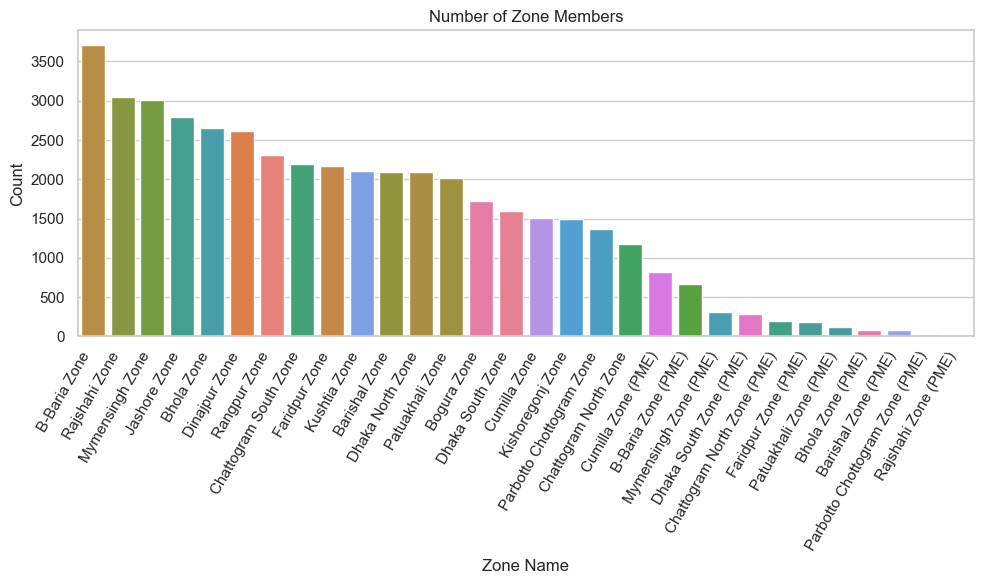

In [61]:
plt.figure(figsize=(10,6))
order = df['zone_name'].value_counts().index
sns.countplot(
    data=df,
    x='zone_name',
    hue='zone_name',
    # palette='Set2',
    # legend=False
    order=order,
    palette=sns.color_palette("husl", len(order)),
    legend=False
)
plt.title('Number of Zone Members')
plt.xlabel('Zone Name')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


In [38]:
table = (
    df['permanent_addr_thana']
    .value_counts()
    .reset_index()
)
table.columns = ['permanent_addr_thana', 'Count']
table = table.sort_values(by='Count', ascending=False)

table.head()

,permanent_addr_thana,Count
0,Gaffargaon,1126
1,Sreepur,832
2,Bhola Sadar,743
3,Charfassion,626
4,Borhanuddin,609


In [21]:
table = (
    df.groupby(['branch_name', 'permanent_addr_thana'])
      .size()
      .reset_index(name='Count')
      .sort_values(by='Count', ascending=False)
)

# display(table)
table.head()

,branch_name,permanent_addr_thana,Count
211,Godkhali Branch,Jhikargachha,221
367,Meherpur Sadar Branch,Meherpur,219
138,Chhatak Branch,Chhatak,211
156,Darshana Branch,Darshana,203
470,Rowmari Branch,Rowmari,202


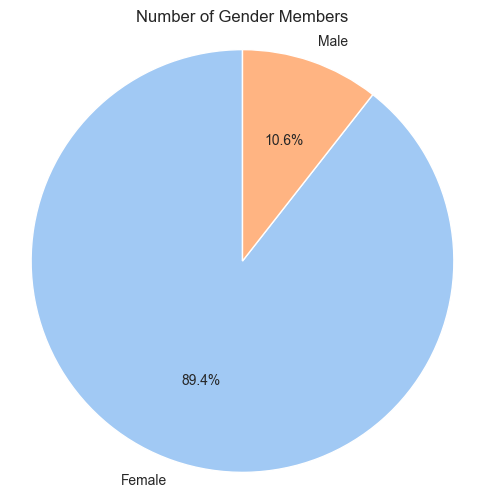

In [43]:
gender_counts = df['gender'].value_counts()

colors = sns.color_palette('pastel')

plt.figure(figsize=(6,6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors)

plt.title('Number of Gender Members')
plt.axis('equal')
plt.show()

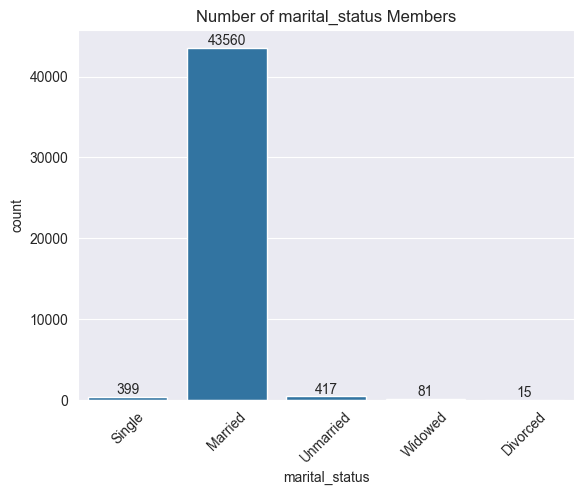

In [40]:
ax=sns.countplot(data=df, x='marital_status')
ax.bar_label(ax.containers[0])
plt.title('Number of marital_status Members')
plt.xticks(rotation=45)
plt.show()

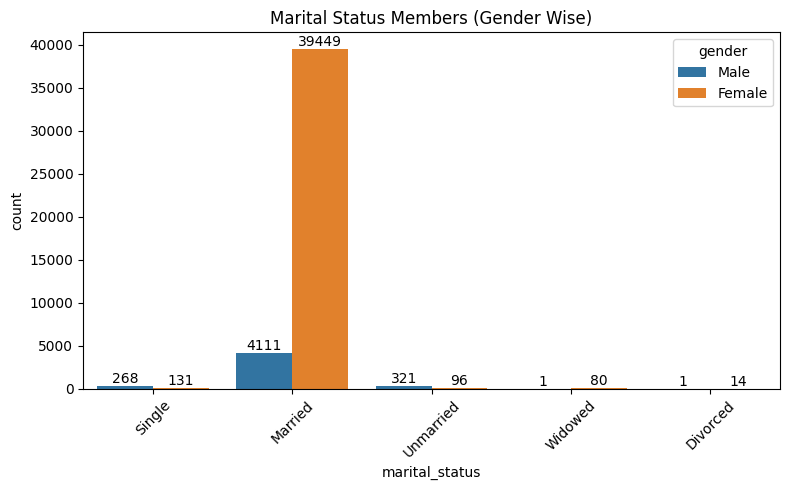

In [61]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='marital_status',
    hue='gender'
)

# add labels for each group
for container in ax.containers:
    ax.bar_label(container)

plt.title('Marital Status Members (Gender Wise)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
table = (
    df[
        df['passport_expire_date'].notna() &
        (df['passport_expire_date'] != '0000-00-00')
    ]
    .groupby(['branch_name', 'permanent_addr_thana'])
    .size()
    .reset_index(name='Count')
    .sort_values(by='Count', ascending=False)
)
table.head()

,branch_name,permanent_addr_thana,Count
211,Godkhali Branch,Jhikargachha,219
367,Meherpur Sadar Branch,Meherpur,219
138,Chhatak Branch,Chhatak,211
156,Darshana Branch,Darshana,203
470,Rowmari Branch,Rowmari,202
